# Regresión Logística - Clasificación de Sistema Operativo

En esta notebook vamos a predecir qué sistema operativo utiliza un usuario
en base a su comportamiento en un sitio web.

**Características de entrada:**
- `duracion_segundos`: Duración de la visita en segundos
- `paginas_vistas`: Cantidad de páginas vistas durante la sesión
- `cantidad_acciones`: Cantidad de acciones del usuario
- `valor_acciones`: Suma del valor de las acciones

**Etiquetas de salida:**
- `0` → Windows
- `1` → Macintosh
- `2` → Linux

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns


## 2. Cargar y explorar los datos

In [2]:
# Cargamos el dataset
import pandas as pd
df = pd.read_csv(r'C:\Users\usuario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\01 - Ejercicios Entrega\Semana 4\usuarios_win_mac_lin.csv')
print('Shape del dataset:', df.shape)
df.head()

Shape del dataset: (170, 5)


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [3]:
# Información general del dataset
print('Forma del dataset:', df.shape)
print('\nInformación general:')
df.info()

Forma del dataset: (170, 5)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [4]:
df.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


In [5]:
# Distribución de sistemas operativos
etiquetas = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
conteo = df['clase'].value_counts().rename(etiquetas)
print('Distribución de sistemas operativos:')
print(conteo)

Distribución de sistemas operativos:
clase
Windows      86
Linux        44
Macintosh    40
Name: count, dtype: int64


## 3. Visualización exploratoria de los datos

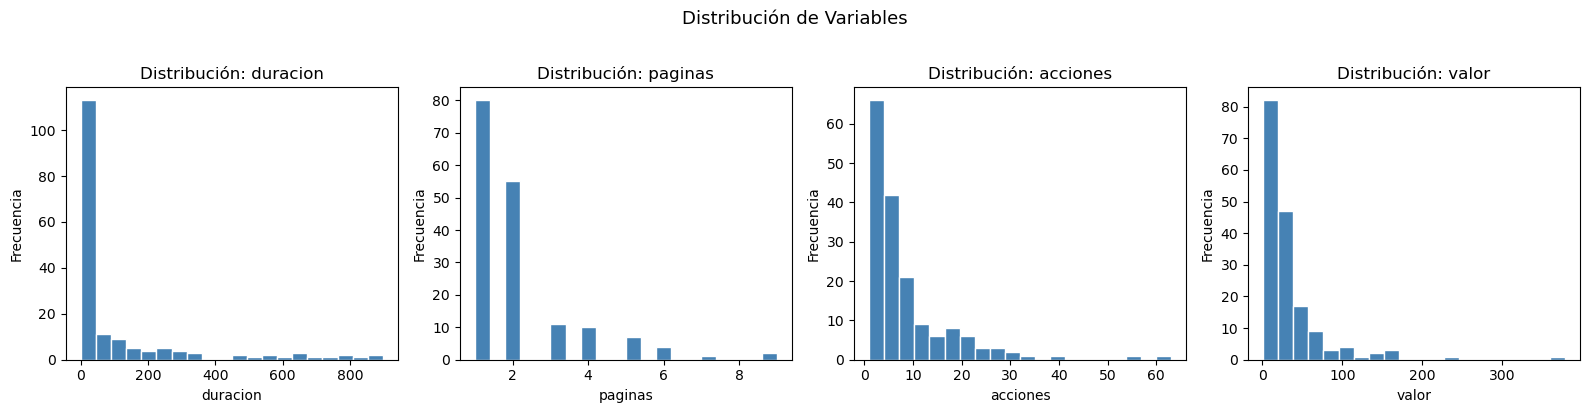

In [6]:
variables = ['duracion', 'paginas', 'acciones', 'valor']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, var in zip(axes, variables):
    ax.hist(df[var], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución: {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

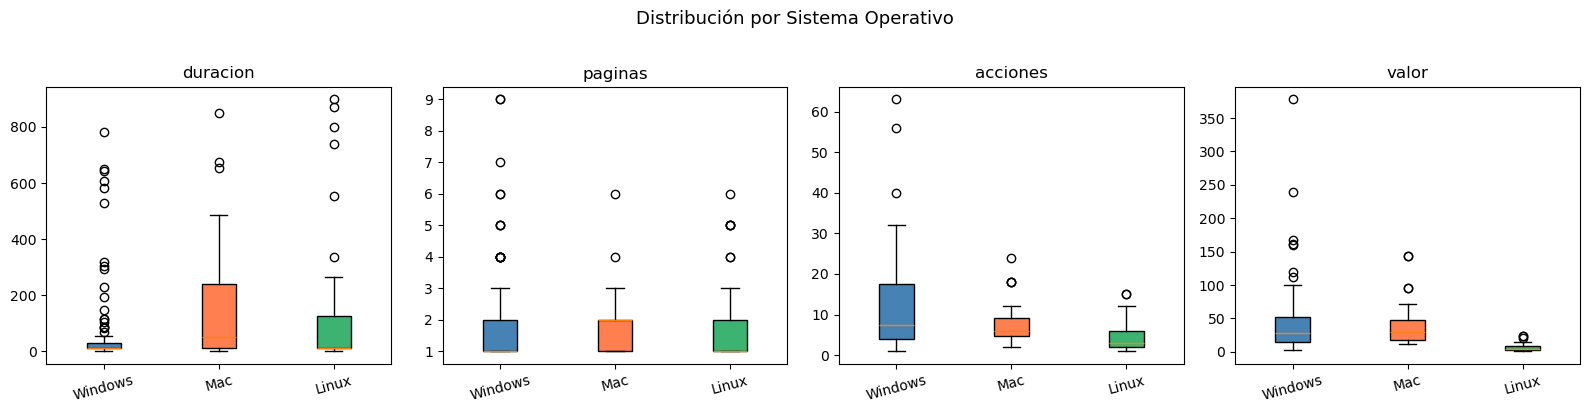

In [7]:
df['so'] = df['clase'].map({0: 'Windows', 1: 'Macintosh', 2: 'Linux'})
variables = ['duracion', 'paginas', 'acciones', 'valor']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, var in zip(axes, variables):
    grupos = [df[df['so'] == so][var].values
              for so in ['Windows', 'Macintosh', 'Linux']]
    bp = ax.boxplot(grupos, patch_artist=True,
                    tick_labels=['Windows', 'Mac', 'Linux'])
    for patch, color in zip(bp['boxes'],
                            ['steelblue', 'coral', 'mediumseagreen']):
        patch.set_facecolor(color)
    ax.set_title(var)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Distribución por Sistema Operativo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

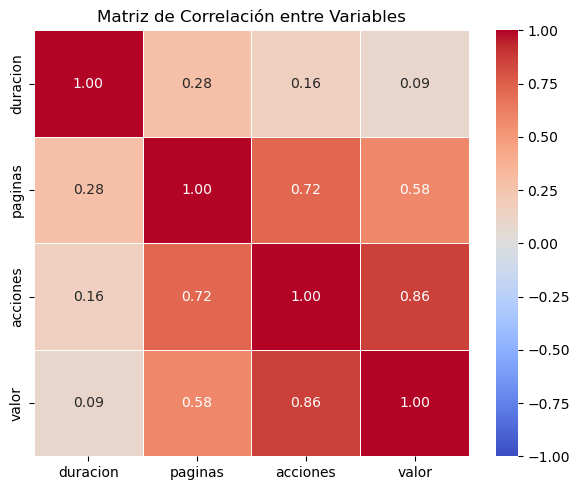

In [8]:
corr = df[['duracion', 'paginas', 'acciones', 'valor']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Variables')
plt.tight_layout()
plt.show()

## 4. Preparar los datos para el modelo

In [9]:
# Separamos las características (X) de las etiquetas (Y)
X = df[['duracion', 'paginas', 'acciones', 'valor']].values
Y = df['clase'].values

print('\nPrimeros 5 valores de X:')
print(X[:5])
print('\nPrimeros 5 valores de Y:')
print(Y[:5])


Primeros 5 valores de X:
[[  7.   2.   4.   8.]
 [ 21.   2.   6.   6.]
 [ 57.   2.   4.   4.]
 [101.   3.   6.  12.]
 [109.   2.   6.  12.]]

Primeros 5 valores de Y:
[2 2 2 2 2]


In [10]:
# Dividimos en datos de entrenamiento (80%) y de prueba (20%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print('Datos de entrenamiento:', X_train.shape)
print('Datos de prueba:       ', X_test.shape)

Datos de entrenamiento: (136, 4)
Datos de prueba:        (34, 4)


## 5. Crear y entrenar el modelo

In [11]:
# Creamos el clasificador de Regresión Logística
clasificador = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
clasificador.fit(X_train, Y_train)

print('Modelo entrenado correctamente ✓')

Modelo entrenado correctamente ✓


## 6. Evaluación del modelo

In [12]:
# Predicción sobre los datos de prueba
Y_pred = clasificador.predict(X_test)

print('Valores reales:    ', Y_test)
print('Valores predichos: ', Y_pred)

Valores reales:     [0 1 2 1 0 0 0 0 1 0 2 0 0 1 0 0 1 1 0 1 1 2 1 1 2 2 0 1 0 0 1 0 0 2]
Valores predichos:  [0 1 2 1 0 0 0 0 0 2 2 0 0 1 0 0 0 0 1 0 0 2 1 0 2 2 0 0 1 0 0 0 0 2]


In [13]:
# Accuracy (precisión global)
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy del modelo: {accuracy * 100:.2f}%')

Accuracy del modelo: 67.65%


## 7. Predicción de nuevos usuarios

In [14]:
# Definimos nuevos usuarios con sus características
nuevos_usuarios = np.array([
    [300, 7, 18, 52],   # Usuario A
    [750, 16, 11, 98],  # Usuario B
    [60,  2,  40, 22],  # Usuario C
])

# Realizamos la predicción
predicciones = clasificador.predict(nuevos_usuarios)
probabilidades = clasificador.predict_proba(nuevos_usuarios)
nombres_so = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
print('Predicciones para nuevos usuarios:')
print('=' * 55)
for i, (pred, proba) in enumerate(zip(predicciones, probabilidades)):
    so = nombres_so[pred]
    print(f'\nUsuario {chr(65+i)}: {nuevos_usuarios[i]}')
    print(f'  → Sistema Operativo predicho: {so} ({pred})')
    print(f'  → Probabilidades: Windows={proba[0]:.2%} | Mac={proba[1]:.2%} | Linux={proba[2]:.2%}')

Predicciones para nuevos usuarios:

Usuario A: [300   7  18  52]
  → Sistema Operativo predicho: Windows (0)
  → Probabilidades: Windows=84.16% | Mac=15.84% | Linux=0.00%

Usuario B: [750  16  11  98]
  → Sistema Operativo predicho: Macintosh (1)
  → Probabilidades: Windows=0.10% | Mac=99.90% | Linux=0.00%

Usuario C: [60  2 40 22]
  → Sistema Operativo predicho: Linux (2)
  → Probabilidades: Windows=0.00% | Mac=0.00% | Linux=100.00%


## 8. Visualización de la zona de decisión (2 características)

Como solo podemos graficar en 2D, usamos las dos características más representativas: **duración** y **páginas vistas**

Varianza explicada: PC1=95%, PC2=5%, Total=100%
Clases en la malla: [0 1 2]


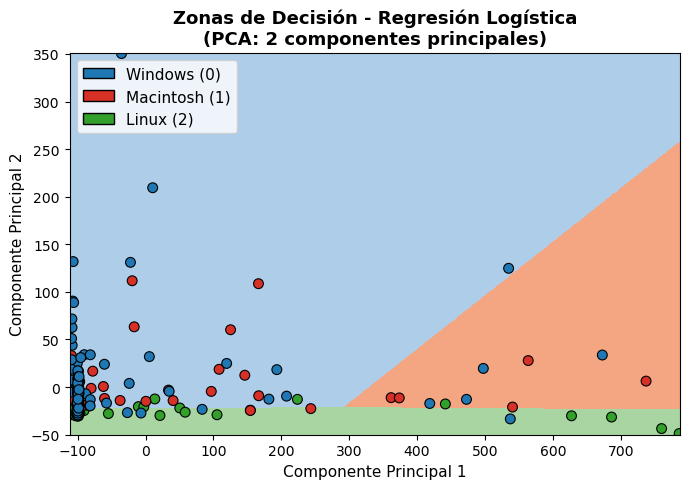

In [15]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

pca = PCA(n_components=2)
X_2d = pca.fit_transform(df[['duracion', 'paginas', 'acciones', 'valor']].values)
Y_2d = df['clase'].values

print(f'Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.0%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.0%}, '
      f'Total={sum(pca.explained_variance_ratio_):.0%}')

clasificador_2d = LogisticRegression(max_iter=1000, random_state=42)
clasificador_2d.fit(X_2d, Y_2d)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

malla = clasificador_2d.predict(np.c_[xx.ravel(), yy.ravel()])
malla = malla.reshape(xx.shape)
print('Clases en la malla:', np.unique(malla))

cmap_fondo  = ListedColormap(['#AECDE8', '#F4A582', '#A8D5A2'])
cmap_puntos = ListedColormap(['#1F78B4', '#D73027', '#33A02C'])

plt.figure(figsize=(7, 5))
plt.pcolormesh(xx, yy, malla, cmap=cmap_fondo, shading='auto')
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=Y_2d,
            cmap=cmap_puntos, s=50,
            edgecolors='black', linewidth=0.8)

leyenda = [
    Patch(facecolor='#1F78B4', edgecolor='black', label='Windows (0)'),
    Patch(facecolor='#D73027', edgecolor='black', label='Macintosh (1)'),
    Patch(facecolor='#33A02C', edgecolor='black', label='Linux (2)'),
]
plt.legend(handles=leyenda, loc='upper left', fontsize=11)
plt.title('Zonas de Decisión - Regresión Logística\n(PCA: 2 componentes principales)',
          fontsize=13, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=11)
plt.ylabel('Componente Principal 2', fontsize=11)
plt.tight_layout()
plt.show()

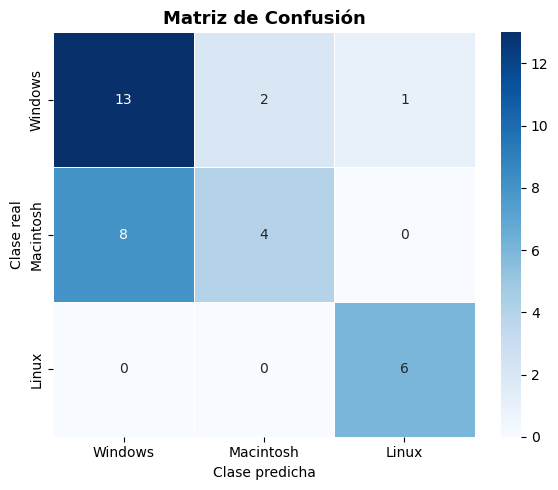

              precision    recall  f1-score   support

     Windows       0.62      0.81      0.70        16
   Macintosh       0.67      0.33      0.44        12
       Linux       0.86      1.00      0.92         6

    accuracy                           0.68        34
   macro avg       0.71      0.72      0.69        34
weighted avg       0.68      0.68      0.65        34



In [16]:
# Matriz de confusión
cm = confusion_matrix(Y_test, Y_pred)
nombres_so = ['Windows', 'Macintosh', 'Linux']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_so,
            yticklabels=nombres_so,
            linewidths=0.5)
plt.title('Matriz de Confusión', fontsize=13, fontweight='bold')
plt.ylabel('Clase real')
plt.xlabel('Clase predicha')
plt.tight_layout()
plt.show()

# Reporte completo por clase
print(classification_report(Y_test, Y_pred,
      target_names=nombres_so))

## Conclusión

En este ejercicio se aplicó un modelo de Regresión Logística para clasificar el sistema operativo utilizado por distintos usuarios a partir de variables relacionadas con su comportamiento en un sitio web, como la duración de la visita, la cantidad de páginas vistas, las acciones realizadas y el valor de esas acciones.

Durante el análisis exploratorio se observó que el dataset contiene 170 registros y no presenta valores nulos, lo cual permitió trabajar directamente con las variables disponibles. También se identificó que las clases no están completamente equilibradas, ya que Windows es la categoría con mayor cantidad de registros, seguida por Linux y Macintosh.

Luego de entrenar el modelo y evaluarlo con datos de prueba, se obtuvo un accuracy aproximado del 67,65%. Este resultado indica que el modelo logra clasificar correctamente una parte importante de los casos, aunque todavía presenta errores, especialmente en la identificación de usuarios Macintosh.

Al analizar el reporte de clasificación, se observa que el modelo tiene un mejor desempeño para la clase Linux, con un F1-score de 0,92, lo que indica que esta clase se diferencia bastante bien de las demás. En cambio, Macintosh presenta el rendimiento más bajo, con un F1-score de 0,44, debido a que varios usuarios de esta clase fueron clasificados incorrectamente como Windows.

En conclusión, el modelo permite realizar una primera aproximación al problema de clasificación de sistemas operativos a partir del comportamiento de los usuarios. Sin embargo, el accuracy general no muestra toda la realidad del modelo, ya que el desempeño varía según cada clase. Para mejorar los resultados, sería conveniente ampliar el dataset, equilibrar mejor las clases, probar otros modelos de clasificación y aplicar técnicas de normalización o ajuste de hiperparámetros.